# Sachit Anand — Parks Sub-metric
### CMP 0011 Final Project | Group 4 — Fun Finder Pittsburgh

**Research Question:** What is the most fun neighborhood in Pittsburgh?

**My Sub-metric:** Number of parks per neighborhood

**Dataset:** [City of Pittsburgh Parks — WPRDC](https://data.wprdc.org/dataset/city-parks)

**Team Members:** Sachit Anand, Rhonda Ojongmboh, Osarumen Okhiku

---
## 1. Introduction

Our team defined the "most fun" neighborhood in Pittsburgh as the one with the most public recreational infrastructure. Fun, in this context, means having the most places to go outside and be active. My contribution to this definition is parks — green spaces maintained by the City of Pittsburgh where residents can relax, play sports, walk dogs, and gather as a community.

A neighborhood with more parks simply has more options. Whether you want a quiet bench or a wide open field, parks are one of the most accessible forms of public recreation because they are free, open to everyone, and spread throughout the city.

In this notebook I will:
1. Load and explore the City of Pittsburgh Parks dataset
2. Count the number of parks in each neighborhood
3. Visualize the distribution with bar and pie charts
4. Identify the top neighborhood by park count
5. Export a normalized score for use in the group combined metric

---
## 2. Setup

In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.ticker as ticker
import os

pd.set_option('display.max_columns', None)
plt.rcParams['figure.figsize'] = (12, 6)
plt.rcParams['axes.spines.top'] = False
plt.rcParams['axes.spines.right'] = False

# Make sure data/ output folder exists
os.makedirs('data', exist_ok=True)
print('Libraries loaded successfully.')

Libraries loaded successfully.


---
## 3. Load the Data

In [2]:
# Load from local CSV (place parks.csv inside a data/ folder next to this notebook)
parks = pd.read_csv('data/parks.csv')

print(f'Rows: {len(parks)}')
print(f'Columns: {list(parks.columns)}')
parks.head()

Rows: 209
Columns: ['_id', 'id', 'name', 'type', 'maintenance_responsibility', 'image', 'neighborhood', 'council_district', 'ward', 'tract', 'public_works_division', 'pli_division', 'police_zone', 'fire_zone', 'latitude', 'longitude']


,_id,id,name,type,maintenance_responsibility,image,neighborhood,council_district,ward,tract,public_works_division,pli_division,police_zone,fire_zone,latitude,longitude
0,1,2111959181,Able Long Park,Park,Parks - Southern,https://tools.wprdc.org/images/pittsburgh/park...,Beechview,4,19,42003192000,5,19,6,4-28,40.408118,-80.028197
1,2,1109513049,Albert Turk Graham Park,Park,Parks - Schenley,https://tools.wprdc.org/images/pittsburgh/park...,Crawford-Roberts,6,3,42003030500,3,3,2,2-1,40.440507,-79.984018
2,3,1544096765,Alcoa Park,Park,Parks - Northern,NaN,North Shore,1,22,42003563200,6,22,1,1-20,40.447481,-80.001017
3,4,1212681573,Allegheny Commons,Park,Parks - Northern,NaN,Allegheny Center,1,22,42003562700,1,22,1,1-7,40.453126,-80.009158
4,5,954863286,Allegheny Landing Park,Park,Parks - Northern,NaN,North Shore,1,22,42003563200,6,22,1,1-20,40.447184,-80.002907


---
## 4. Explore the Data

In [3]:
print(f'Total parks in the dataset: {len(parks)}')
print(f'Unique neighborhoods with at least one park: {parks["neighborhood"].nunique()}')
print(f'\nMissing values per column:')
print(parks.isnull().sum())

Total parks in the dataset: 209
Unique neighborhoods with at least one park: 73

Missing values per column:
_id                             0
id                              0
name                            0
type                            0
maintenance_responsibility      0
image                         146
neighborhood                    0
council_district                0
ward                            0
tract                           0
public_works_division           0
pli_division                    0
police_zone                     0
fire_zone                       0
latitude                        0
longitude                       0
dtype: int64


In [4]:
# What types of parks are in the dataset?
print('Park types:')
print(parks['type'].value_counts())

print('\nWho maintains the parks?')
print(parks['maintenance_responsibility'].value_counts())

Park types:
type
Park                     153
Traffic Island/Median     33
Building Grounds          10
Monument/Memorial          7
Open Space                 6
Name: count, dtype: int64

Who maintains the parks?
maintenance_responsibility
Parks - Northern     39
Parks - Western      32
Parks - Southern     29
Parks - Northeast    25
Parks - Schenley     23
Parks - Eastern      22
3rd Division         19
2nd Division         10
6th Division          5
5th Division          3
4th Division          1
1st Division          1
Name: count, dtype: int64


In [5]:
# Quick look at the neighborhood column
print('Sample of neighborhood values:')
print(parks['neighborhood'].value_counts().head(10))

Sample of neighborhood values:
neighborhood
East Liberty                 12
Central Business District    10
Beechview                     8
South Side Slopes             7
Point Breeze                  7
Hazelwood                     6
Squirrel Hill South           6
South Side Flats              6
Mount Washington              6
Sheraden                      6
Name: count, dtype: int64


---
## 5. Count Parks per Neighborhood

In [6]:
# Remove any rows where neighborhood is missing
parks_clean = parks.dropna(subset=['neighborhood']).copy()
print(f'Rows after dropping missing neighborhoods: {len(parks_clean)}')

# Count parks per neighborhood and sort descending
parks_per_hood = (
    parks_clean
    .groupby('neighborhood')
    .size()
    .reset_index(name='park_count')
    .sort_values('park_count', ascending=False)
    .reset_index(drop=True)
)

print(f'\nNeighborhoods ranked by park count (top 15):')
print(parks_per_hood.head(15).to_string(index=False))

Rows after dropping missing neighborhoods: 209

Neighborhoods ranked by park count (top 15):
             neighborhood  park_count
             East Liberty          12
Central Business District          10
                Beechview           8
             Point Breeze           7
        South Side Slopes           7
      Squirrel Hill South           6
                Hazelwood           6
                 Sheraden           6
         Mount Washington           6
         South Side Flats           6
            South Oakland           5
                Troy Hill           5
          Central Oakland           4
                  Elliott           4
         Brighton Heights           4


---
## 6. Visualizations

/scratch/slurm-35760/ipykernel_4023725/912765709.py:20: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax.set_xticklabels(top15['neighborhood'], rotation=45, ha='right', fontsize=10)


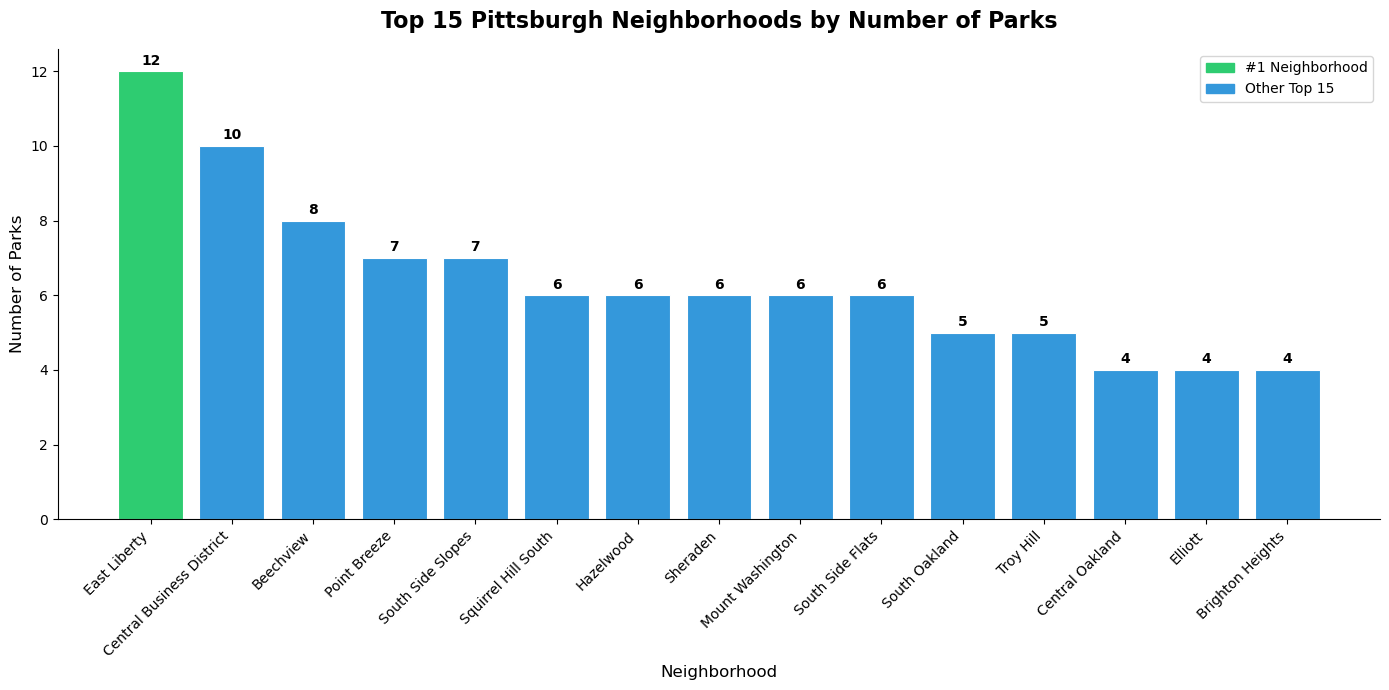

Saved: parks_top15.png


In [7]:
# ── Chart 1: Top 15 neighborhoods by park count ──────────────────────────────
top15 = parks_per_hood.head(15)

fig, ax = plt.subplots(figsize=(14, 7))

colors = ['#2ecc71' if i == 0 else '#3498db' for i in range(len(top15))]
bars = ax.bar(top15['neighborhood'], top15['park_count'],
              color=colors, edgecolor='white', linewidth=0.8)

# Label each bar with its count
for bar in bars:
    ax.text(bar.get_x() + bar.get_width() / 2, bar.get_height() + 0.1,
            str(int(bar.get_height())), ha='center', va='bottom',
            fontsize=10, fontweight='bold')

ax.set_title('Top 15 Pittsburgh Neighborhoods by Number of Parks',
             fontsize=16, fontweight='bold', pad=15)
ax.set_xlabel('Neighborhood', fontsize=12)
ax.set_ylabel('Number of Parks', fontsize=12)
ax.set_xticklabels(top15['neighborhood'], rotation=45, ha='right', fontsize=10)
ax.yaxis.set_major_locator(ticker.MaxNLocator(integer=True))
ax.legend(handles=[
    plt.Rectangle((0,0),1,1, color='#2ecc71', label='#1 Neighborhood'),
    plt.Rectangle((0,0),1,1, color='#3498db', label='Other Top 15')
], fontsize=10)

plt.tight_layout()
plt.savefig('parks_top15.png', dpi=150, bbox_inches='tight')
plt.show()
print('Saved: parks_top15.png')

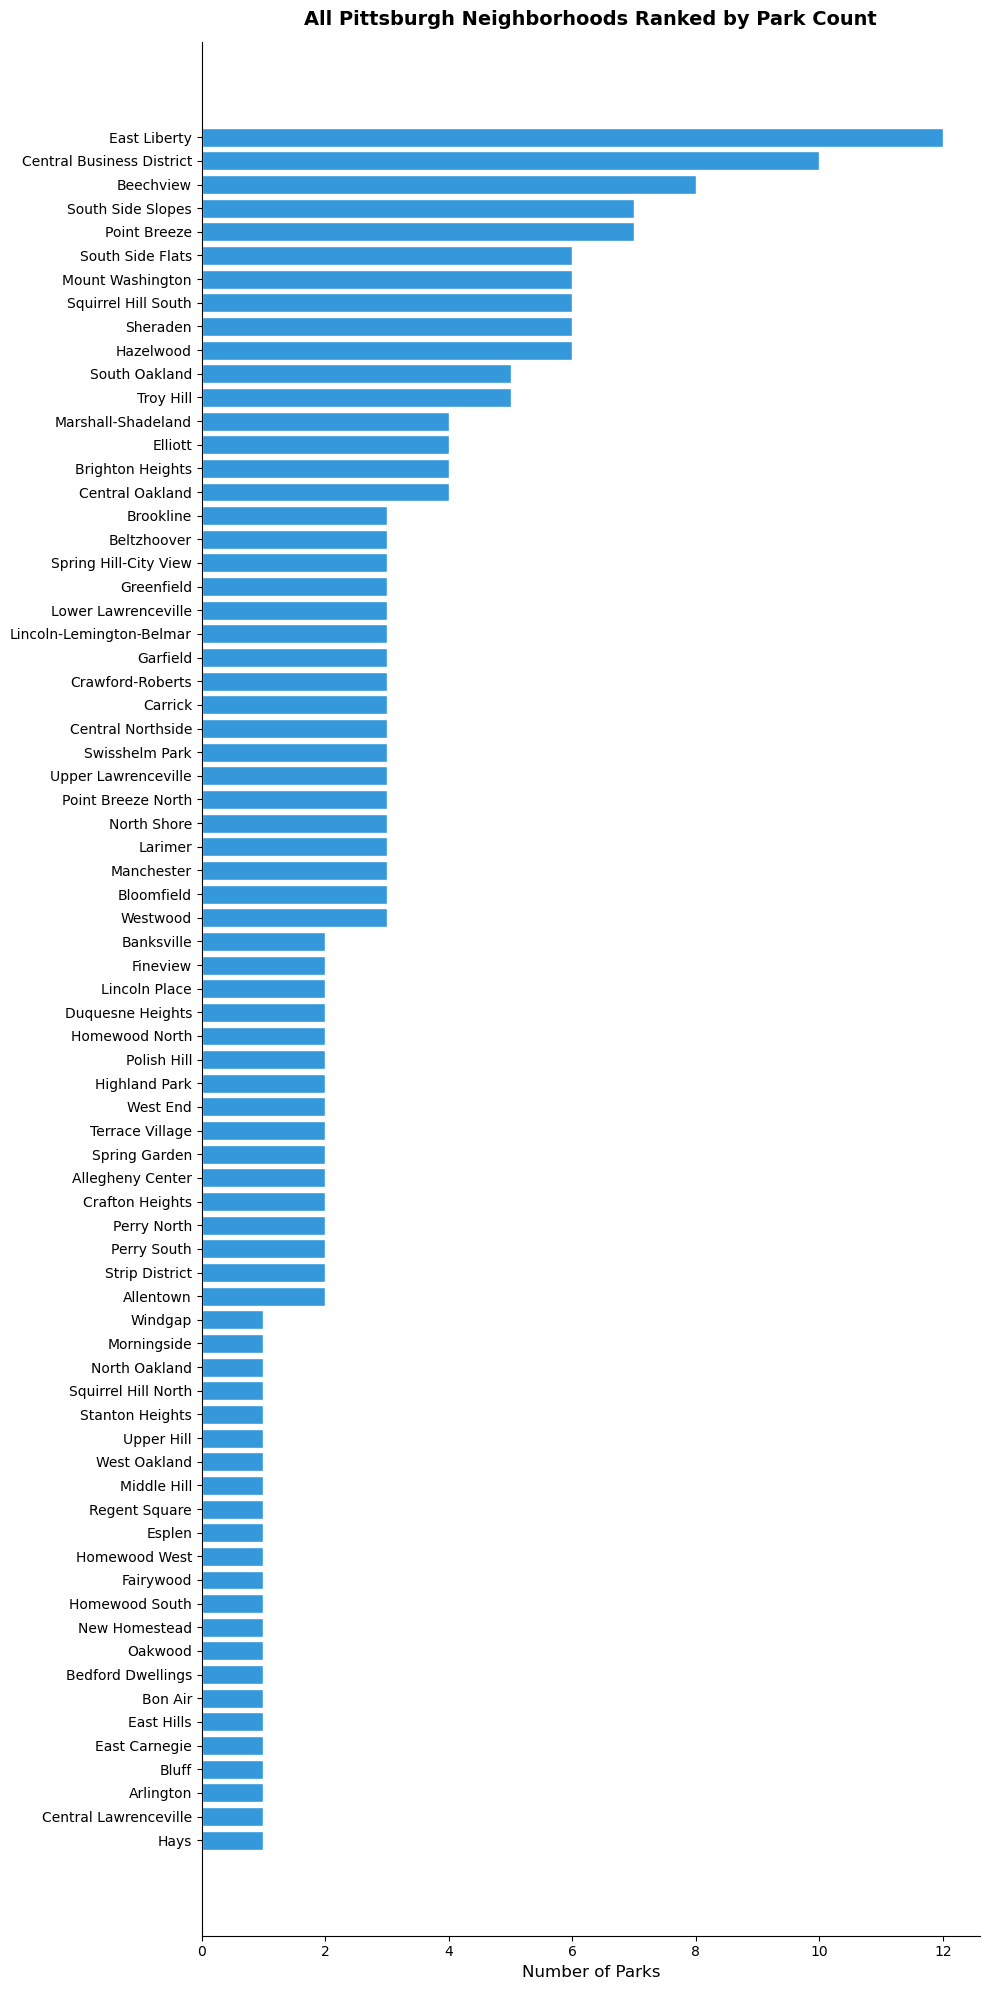

Saved: parks_all_neighborhoods.png


In [8]:
# ── Chart 2: All neighborhoods ranked (horizontal) ───────────────────────────
sorted_all = parks_per_hood.sort_values('park_count')

fig, ax = plt.subplots(figsize=(10, 20))
ax.barh(sorted_all['neighborhood'], sorted_all['park_count'],
        color='#3498db', edgecolor='white')

ax.set_title('All Pittsburgh Neighborhoods Ranked by Park Count',
             fontsize=14, fontweight='bold', pad=12)
ax.set_xlabel('Number of Parks', fontsize=12)
ax.xaxis.set_major_locator(ticker.MaxNLocator(integer=True))

plt.tight_layout()
plt.savefig('parks_all_neighborhoods.png', dpi=150, bbox_inches='tight')
plt.show()
print('Saved: parks_all_neighborhoods.png')

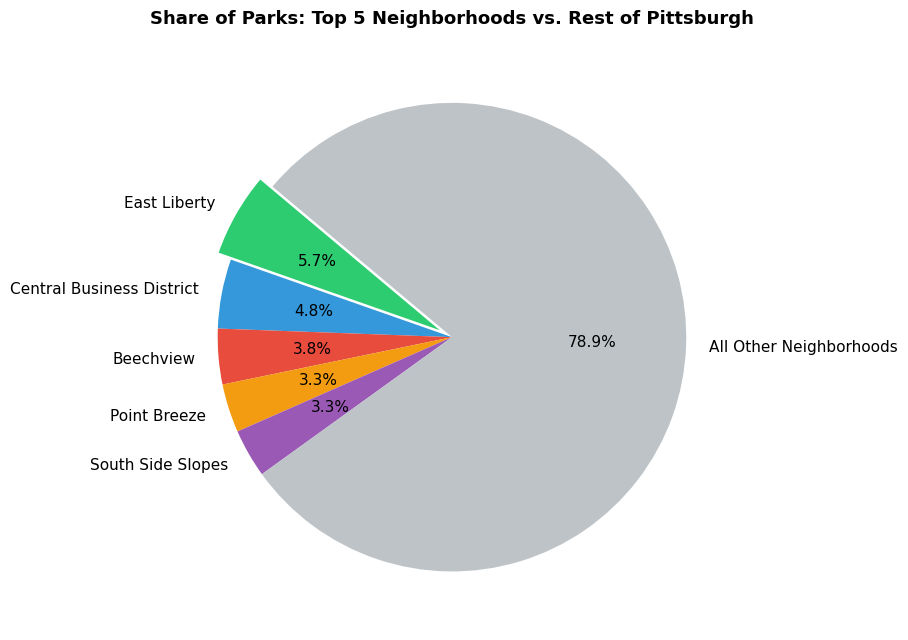

Saved: parks_pie.png


In [9]:
# ── Chart 3: Pie — top 5 vs. rest of Pittsburgh ───────────────────────────────
top5        = parks_per_hood.head(5)
rest_count  = parks_per_hood.iloc[5:]['park_count'].sum()

labels  = list(top5['neighborhood']) + ['All Other Neighborhoods']
sizes   = list(top5['park_count'])   + [rest_count]
colors  = ['#2ecc71','#3498db','#e74c3c','#f39c12','#9b59b6','#bdc3c7']
explode = [0.06] + [0] * 5

fig, ax = plt.subplots(figsize=(9, 9))
ax.pie(sizes, labels=labels, colors=colors, explode=explode,
       autopct='%1.1f%%', startangle=140, textprops={'fontsize': 11})
ax.set_title('Share of Parks: Top 5 Neighborhoods vs. Rest of Pittsburgh',
             fontsize=13, fontweight='bold', pad=15)

plt.tight_layout()
plt.savefig('parks_pie.png', dpi=150, bbox_inches='tight')
plt.show()
print('Saved: parks_pie.png')

---
## 7. Results

In [10]:
winner = parks_per_hood.iloc[0]
total_parks = parks_per_hood['park_count'].sum()

print('=' * 52)
print(f'  Parks Sub-metric Winner: {winner["neighborhood"]}')
print(f'  Park count:   {winner["park_count"]}')
print(f'  % of all city parks: {winner["park_count"]/total_parks*100:.1f}%')
print('=' * 52)
print()
print('Full top 5:')
print(parks_per_hood.head(5).to_string(index=False))

  Parks Sub-metric Winner: East Liberty
  Park count:   12
  % of all city parks: 5.7%

Full top 5:
             neighborhood  park_count
             East Liberty          12
Central Business District          10
                Beechview           8
             Point Breeze           7
        South Side Slopes           7


**East Liberty** leads with 12 parks — 4 more than the second-place Central Business District (10) and exactly double the count of neighborhoods like Squirrel Hill South, Hazelwood, and Mount Washington (6 each). East Liberty accounts for about 5.7% of all city parks on its own, which is a significant concentration in a single neighborhood.

---
## 8. Normalized Score for Group Combination

To combine this sub-metric fairly with Rhonda's playgrounds score and Osarumen's courts/rinks score, the park count is normalized to a 0–1 scale where 1.0 = the neighborhood with the most parks (East Liberty, 12).

In [11]:
parks_per_hood['park_score'] = (
    parks_per_hood['park_count'] / parks_per_hood['park_count'].max()
)

# Export for use in the group notebook
parks_per_hood[['neighborhood', 'park_count', 'park_score']].to_csv(
    'data/parks_scores.csv', index=False
)

print('Exported: data/parks_scores.csv')
print()
print('Top 10 with normalized scores:')
print(parks_per_hood[['neighborhood', 'park_count', 'park_score']].head(10).to_string(index=False))

Exported: data/parks_scores.csv

Top 10 with normalized scores:
             neighborhood  park_count  park_score
             East Liberty          12    1.000000
Central Business District          10    0.833333
                Beechview           8    0.666667
             Point Breeze           7    0.583333
        South Side Slopes           7    0.583333
      Squirrel Hill South           6    0.500000
                Hazelwood           6    0.500000
                 Sheraden           6    0.500000
         Mount Washington           6    0.500000
         South Side Flats           6    0.500000


---
## 9. Conclusion

Based on the parks sub-metric alone, **East Liberty** is the most fun neighborhood in Pittsburgh with 12 city parks — more than any other neighborhood. East Liberty is a well-known hub in Pittsburgh that has undergone significant revitalization over the past decade, and its high park count reflects an investment in public outdoor space that gives residents a wide range of places to enjoy.

That said, parks by themselves only tell part of the story. A neighborhood could have many parks that are small or lack equipment. When combined with Rhonda's playground count and Osarumen's courts and rinks count, we get a much more complete picture of where Pittsburgh residents have the most recreational options.

The only missing values are in the image column which is not used in this analysis. The neighborhood column has zero missing values so the park count is fully accurate.

**Personal reflection:** Personally, I would have guessed Squirrel Hill South as Pittsburgh's most fun neighborhood — it has a lively commercial strip, a strong community feel, and seems to have a lot going on. The data shows that East Liberty actually beats it on park count, which surprised me. It goes to show that personal impression of a neighborhood can be shaped more by foot traffic and restaurants than by the number of actual green spaces. After seeing the combined results, Squirrel Hill South wins overall because it dominates in courts and playgrounds even if it falls short on raw park count — which honestly makes sense given how many sports fields and tennis courts I remember seeing there.